# 07 — Myeloid Differentiation Trajectory

## Objective

This notebook investigates transcriptional continuity within the myeloid
compartment of the CID4465 triple-negative breast cancer (TNBC)
microenvironment.

The analysis aims to:

1. Isolate myeloid cells from the tumor microenvironment.
2. Reconstruct a myeloid-specific transcriptional landscape.
3. Examine relationships among monocyte-, macrophage-, and dendritic-like states.
4. Infer an exploratory diffusion pseudotime trajectory.
5. Identify genes and transcriptional programs associated with progression
   along the inferred trajectory.

Because this dataset represents a single tumor sample, pseudotime is interpreted
as transcriptional ordering rather than direct evidence of temporal
differentiation.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Scanpy version:", sc.__version__)

Scanpy version: 1.12.4


/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_8511/3716502796.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [2]:
project_dir = Path("..")

data_dir = project_dir / "data" / "processed"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

adata_path = data_dir / "CID4465_processed.h5ad"

adata = sc.read_h5ad(adata_path)

print(adata)
print("\nShape:", adata.shape)

AnnData object with n_obs × n_vars = 1534 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Shape: (1534, 13514)


In [3]:
print("=== MYELOID ANNOTATION CHECK ===")

print("\nMajor annotation:")
print(
    adata.obs["celltype_major"]
    .value_counts()
)

print("\nMyeloid minor annotations:")
print(
    adata.obs.loc[
        adata.obs["celltype_major"] == "Myeloid",
        "celltype_minor"
    ].value_counts()
)

print("\nDetailed myeloid subsets:")
print(
    adata.obs.loc[
        adata.obs["celltype_major"] == "Myeloid",
        "celltype_subset"
    ].value_counts()
)

=== MYELOID ANNOTATION CHECK ===

Major annotation:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Normal Epithelial      9
Name: count, dtype: int64

Myeloid minor annotations:
celltype_minor
Macrophage                     109
Monocyte                        36
Cycling_Myeloid                 21
DCs                             12
B cells Memory                   0
Luminal Progenitors              0
T cells CD4+                     0
Plasmablasts                     0
PVL Immature                     0
PVL Differentiated               0
NKT cells                        0
NK cells                         0
Mature Luminal                   0
Endothelial Lymphatic LYVE1      0
Endothelial RGS5                 0
CAFs MSC iCAF-like               0
Endothelial CXCL12               0
Endothelial ACKR1                0
Cycling T

In [4]:
myeloid = adata[
    adata.obs["celltype_major"] == "Myeloid"
].copy()

print("Myeloid AnnData:")
print(myeloid)

print("\nShape:", myeloid.shape)

print("\nMinor populations:")
print(
    myeloid.obs["celltype_minor"]
    .value_counts()
)

print("\nDetailed subsets:")
print(
    myeloid.obs["celltype_subset"]
    .value_counts()
)

Myeloid AnnData:
AnnData object with n_obs × n_vars = 178 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Shape: (178, 13514)

Minor populations:
celltype_minor
Macrophage         109
Monocyte            36
Cycling_Myeloid     21
DCs                 12
Name: count, dtype: int64

Detailed subsets:
celltype_subset
Myeloid_c1_LAM1_FABP5             102
Myeloid_c12_Monocyte_1_IL1B        33
Cycling_Myeloid                    21
Myeloid_c9_Macrophage_2_CXCL10      5
Myeloid_c4_DCs_pDC_IRF7             4
Myeloid_c3_cDC1_CLEC9A              3
Myeloid_c8_Monocyt

In [5]:
print("=== MYELOID MATRIX CHECK ===")

print("Cells:", myeloid.n_obs)
print("Genes:", myeloid.n_vars)

print("\nLayers:")
print(list(myeloid.layers.keys()))

print("\nRaw available:")
print(myeloid.raw is not None)

print("\nX range:")
print("Min:", myeloid.X.min())
print("Max:", myeloid.X.max())

if "counts" in myeloid.layers:
    print("\nCounts range:")
    print("Min:", myeloid.layers["counts"].min())
    print("Max:", myeloid.layers["counts"].max())

print("\nlog1p metadata:")
print(myeloid.uns.get("log1p"))

=== MYELOID MATRIX CHECK ===
Cells: 178
Genes: 13514

Layers:
['counts', None]

Raw available:
False

X range:
Min: 0.0
Max: 7.440379

Counts range:
Min: 0
Max: 142

log1p metadata:
{'base': None}


In [6]:
# Reset expression matrix to raw counts for myeloid-specific processing

myeloid.X = myeloid.layers["counts"].copy()

print("Myeloid matrix reset to raw counts.")
print("Shape:", myeloid.shape)

print("\nExpression range:")
print("Min:", myeloid.X.min())
print("Max:", myeloid.X.max())

Myeloid matrix reset to raw counts.
Shape: (178, 13514)

Expression range:
Min: 0
Max: 142


In [7]:
sc.pp.normalize_total(
    myeloid,
    target_sum=1e4
)

sc.pp.log1p(myeloid)

print("Myeloid-specific normalization complete.")

Myeloid-specific normalization complete.


In [8]:
sc.pp.highly_variable_genes(
    myeloid,
    n_top_genes=1500,
    flavor="seurat"
)

print(
    "Number of myeloid-specific HVGs:",
    myeloid.var["highly_variable"].sum()
)

Number of myeloid-specific HVGs: 1501


In [9]:
myeloid.raw = myeloid

print("Full normalized myeloid expression stored in myeloid.raw")
print("Raw shape:", myeloid.raw.shape)

Full normalized myeloid expression stored in myeloid.raw
Raw shape: (178, 13514)


In [10]:
myeloid_hvg = myeloid[
    :,
    myeloid.var["highly_variable"]
].copy()

print("Myeloid HVG matrix:")
print(myeloid_hvg)

Myeloid HVG matrix:
AnnData object with n_obs × n_vars = 178 × 1501
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [11]:
sc.pp.scale(
    myeloid_hvg,
    max_value=10
)

sc.tl.pca(
    myeloid_hvg,
    n_comps=30,
    svd_solver="arpack"
)

print("PCA completed.")
print("PCA coordinates:", myeloid_hvg.obsm["X_pca"].shape)

pca_variance = myeloid_hvg.uns["pca"]["variance_ratio"]

print("\nVariance explained by first 10 PCs:")

for i, variance in enumerate(
    pca_variance[:10],
    start=1
):
    print(f"PC{i}: {variance * 100:.2f}%")

print(
    "\nCumulative PC1-PC10:",
    f"{pca_variance[:10].sum() * 100:.2f}%"
)

PCA completed.
PCA coordinates: (178, 30)

Variance explained by first 10 PCs:
PC1: 2.61%
PC2: 1.95%
PC3: 1.87%
PC4: 1.85%
PC5: 1.80%
PC6: 1.77%
PC7: 1.72%
PC8: 1.68%
PC9: 1.67%
PC10: 1.65%

Cumulative PC1-PC10: 18.56%


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [12]:
sc.pp.neighbors(
    myeloid_hvg,
    n_neighbors=10,
    n_pcs=15
)

sc.tl.umap(
    myeloid_hvg,
    random_state=42
)

print("Myeloid UMAP completed.")

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Myeloid UMAP completed.


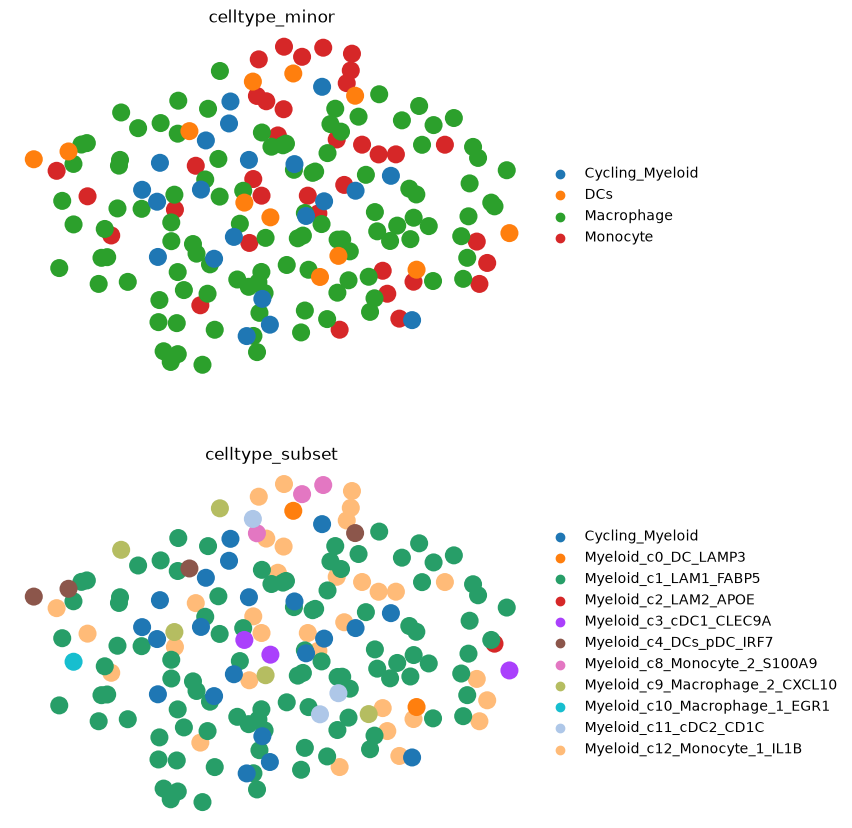

In [13]:
sc.pl.umap(
    myeloid_hvg,
    color=[
        "celltype_minor",
        "celltype_subset"
    ],
    ncols=1,
    frameon=False,
    show=True
)

In [14]:
# Restrict trajectory analysis to the monocyte–macrophage compartment

mono_macro = myeloid[
    myeloid.obs["celltype_minor"].isin(
        ["Monocyte", "Macrophage"]
    )
].copy()

print("Monocyte–macrophage compartment:")
print(mono_macro)

print("\nPopulation composition:")
print(
    mono_macro.obs["celltype_minor"]
    .value_counts()
)

print("\nDetailed subsets:")
print(
    mono_macro.obs["celltype_subset"]
    .value_counts()
)

Monocyte–macrophage compartment:
AnnData object with n_obs × n_vars = 145 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Population composition:
celltype_minor
Macrophage    109
Monocyte       36
Name: count, dtype: int64

Detailed subsets:
celltype_subset
Myeloid_c1_LAM1_FABP5             102
Myeloid_c12_Monocyte_1_IL1B        33
Myeloid_c9_Macrophage_2_CXCL10      5
Myeloid_c8_Monocyte_2_S100A9        3
Myeloid_c2_LAM2_APOE                1
Myeloid_c10_Macrophage_1_EGR1       1
Name: count, dtype: int64


In [15]:
# Recalculate HVGs within the monocyte–macrophage compartment

sc.pp.highly_variable_genes(
    mono_macro,
    n_top_genes=1200,
    flavor="seurat"
)

print(
    "Monocyte–macrophage HVGs:",
    mono_macro.var["highly_variable"].sum()
)

Monocyte–macrophage HVGs: 1207


In [16]:
mono_macro.raw = mono_macro

mono_macro_hvg = mono_macro[
    :,
    mono_macro.var["highly_variable"]
].copy()

print("Trajectory HVG matrix:")
print(mono_macro_hvg)

Trajectory HVG matrix:
AnnData object with n_obs × n_vars = 145 × 1207
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [17]:
sc.pp.scale(
    mono_macro_hvg,
    max_value=10
)

sc.tl.pca(
    mono_macro_hvg,
    n_comps=30,
    svd_solver="arpack"
)

sc.pp.neighbors(
    mono_macro_hvg,
    n_neighbors=10,
    n_pcs=15
)

print("PCA and neighbor graph complete.")
print("PCA shape:", mono_macro_hvg.obsm["X_pca"].shape)

PCA and neighbor graph complete.
PCA shape: (145, 30)


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


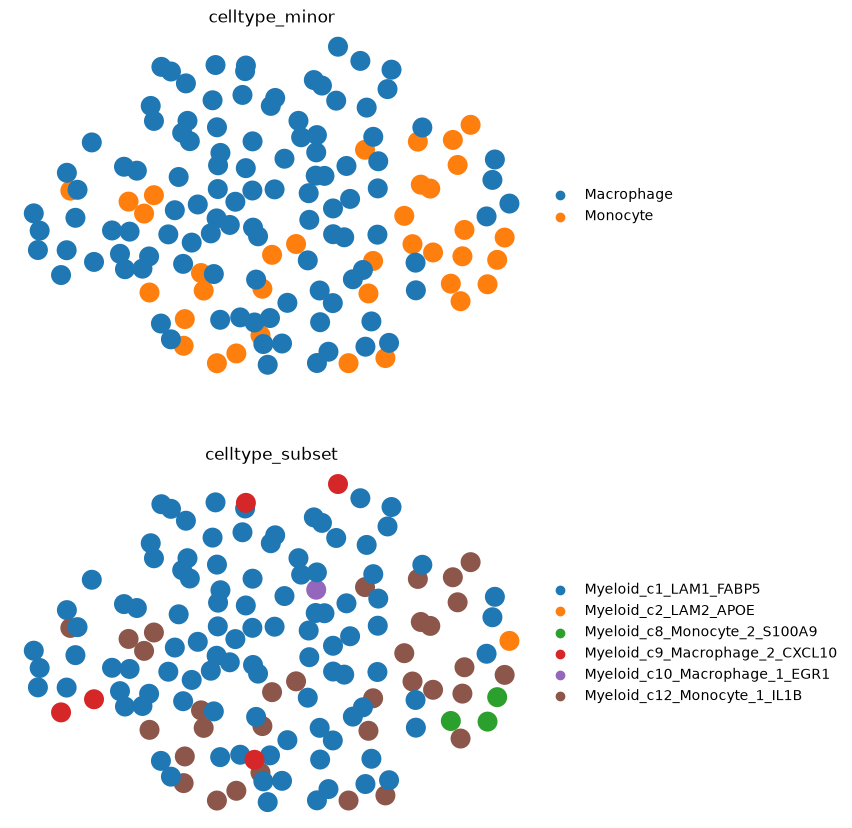

In [18]:
sc.tl.umap(
    mono_macro_hvg,
    random_state=42
)

sc.pl.umap(
    mono_macro_hvg,
    color=[
        "celltype_minor",
        "celltype_subset"
    ],
    ncols=1,
    frameon=False,
    show=True
)

In [19]:
# Diffusion map for trajectory inference

sc.tl.diffmap(
    mono_macro_hvg,
    n_comps=15
)

print(
    "Diffusion components:",
    mono_macro_hvg.obsm["X_diffmap"].shape
)

Diffusion components: (145, 15)


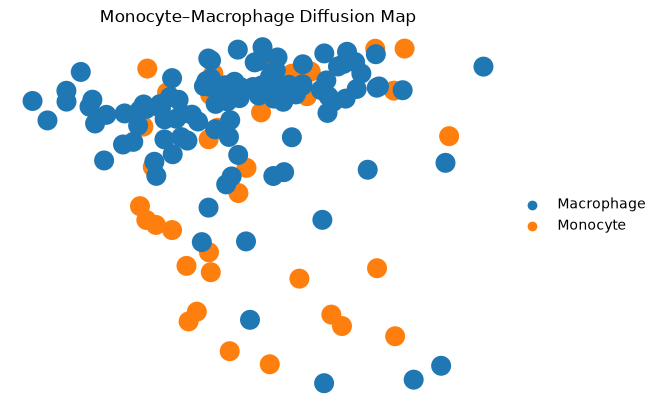

In [20]:
sc.pl.embedding(
    mono_macro_hvg,
    basis="diffmap",
    color="celltype_minor",
    components=["1,2"],
    frameon=False,
    title="Monocyte–Macrophage Diffusion Map",
    show=True
)

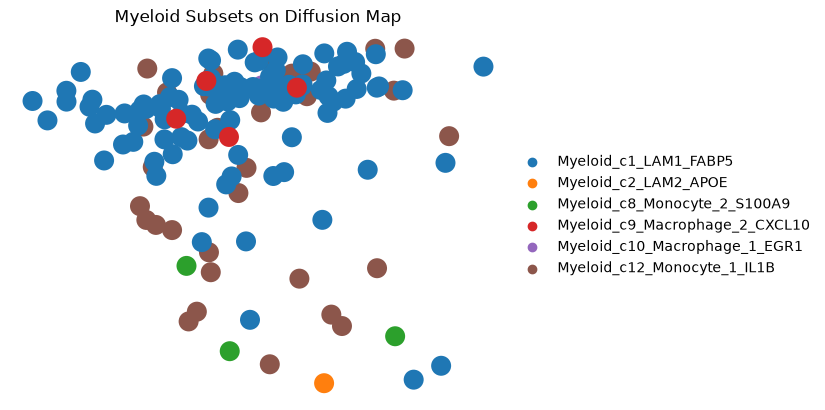

In [21]:
sc.pl.embedding(
    mono_macro_hvg,
    basis="diffmap",
    color="celltype_subset",
    components=["1,2"],
    frameon=False,
    title="Myeloid Subsets on Diffusion Map",
    show=True
)

In [22]:
# Define monocyte- and macrophage-associated transcriptional programs

monocyte_genes = [
    "IL1B",
    "S100A8",
    "S100A9",
    "FCN1",
    "LYZ",
    "CTSS"
]

macrophage_genes = [
    "C1QA",
    "C1QB",
    "C1QC",
    "APOE",
    "LPL",
    "FABP5",
    "LGALS3"
]

monocyte_genes_present = [
    g for g in monocyte_genes
    if g in mono_macro.var_names
]

macrophage_genes_present = [
    g for g in macrophage_genes
    if g in mono_macro.var_names
]

print("Monocyte genes:", monocyte_genes_present)
print("Macrophage genes:", macrophage_genes_present)

sc.tl.score_genes(
    mono_macro,
    monocyte_genes_present,
    score_name="Monocyte_score",
    random_state=42
)

sc.tl.score_genes(
    mono_macro,
    macrophage_genes_present,
    score_name="Macrophage_score",
    random_state=42
)

Monocyte genes: ['IL1B', 'S100A8', 'S100A9', 'FCN1', 'LYZ', 'CTSS']
Macrophage genes: ['C1QA', 'C1QB', 'C1QC', 'APOE', 'LPL', 'FABP5', 'LGALS3']


In [23]:
for col in ["Monocyte_score", "Macrophage_score"]:
    mono_macro_hvg.obs[col] = (
        mono_macro.obs.loc[
            mono_macro_hvg.obs_names,
            col
        ].values
    )

In [24]:
program_summary = (
    mono_macro.obs
    .groupby("celltype_minor", observed=True)[
        ["Monocyte_score", "Macrophage_score"]
    ]
    .mean()
)

print(program_summary.round(3))

                Monocyte_score  Macrophage_score
celltype_minor                                  
Macrophage               0.371             0.978
Monocyte                 0.484            -0.143


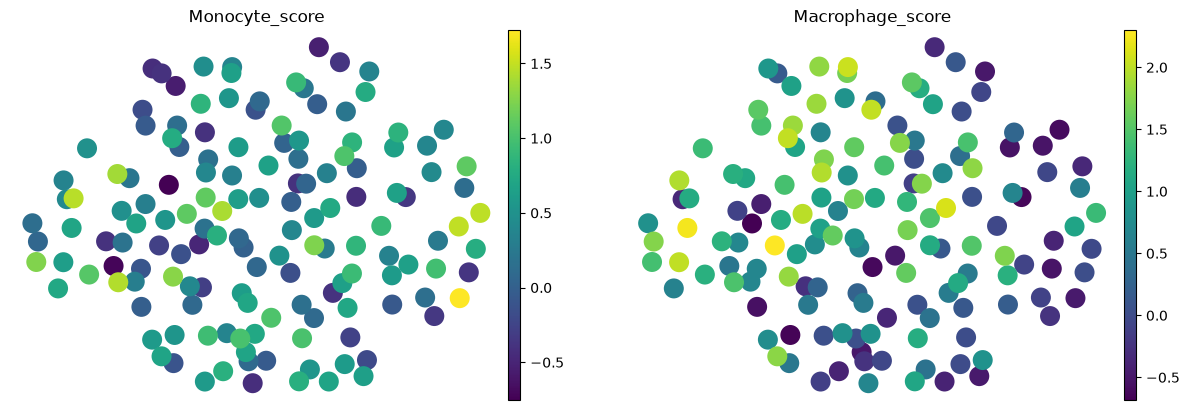

In [25]:
sc.pl.umap(
    mono_macro_hvg,
    color=[
        "Monocyte_score",
        "Macrophage_score"
    ],
    ncols=2,
    frameon=False,
    show=True
)

In [26]:
# Select a biologically informed pseudotime root

root_candidates = mono_macro_hvg.obs[
    mono_macro_hvg.obs["celltype_subset"]
    == "Myeloid_c12_Monocyte_1_IL1B"
].copy()

root_candidates["root_score"] = (
    root_candidates["Monocyte_score"]
    - root_candidates["Macrophage_score"]
)

root_cell = root_candidates["root_score"].idxmax()

root_index = np.where(
    mono_macro_hvg.obs_names == root_cell
)[0][0]

mono_macro_hvg.uns["iroot"] = root_index

print("Selected root cell:", root_cell)
print("Root index:", root_index)

print(
    root_candidates.loc[
        root_cell,
        [
            "Monocyte_score",
            "Macrophage_score",
            "root_score"
        ]
    ]
)

Selected root cell: CID4465_TTAGGACGTTGCGTTA
Root index: 23
Monocyte_score      0.973503
Macrophage_score   -0.522285
root_score          1.495788
Name: CID4465_TTAGGACGTTGCGTTA, dtype: object


In [27]:
# Diffusion pseudotime

sc.tl.dpt(
    mono_macro_hvg,
    n_dcs=10
)

print("DPT completed.")

print(
    mono_macro_hvg.obs["dpt_pseudotime"]
    .describe()
)

DPT completed.
count    145.000000
mean       0.696296
std        0.192234
min        0.000000
25%        0.653678
50%        0.744905
75%        0.815396
max        1.000000
Name: dpt_pseudotime, dtype: float64


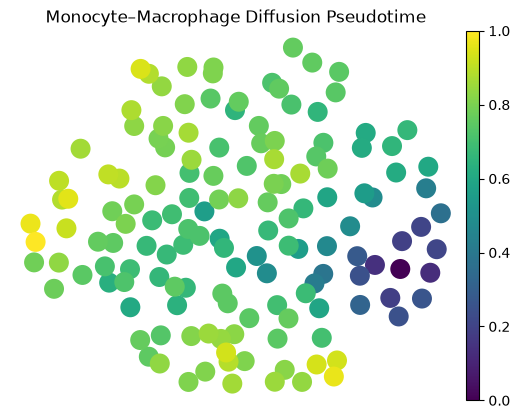

In [28]:
sc.pl.umap(
    mono_macro_hvg,
    color="dpt_pseudotime",
    title="Monocyte–Macrophage Diffusion Pseudotime",
    frameon=False,
    show=True
)

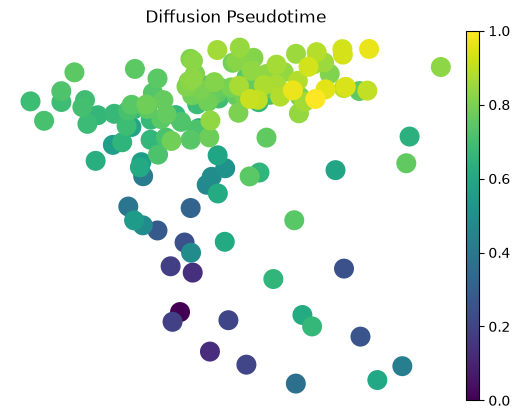

In [29]:
sc.pl.embedding(
    mono_macro_hvg,
    basis="diffmap",
    color="dpt_pseudotime",
    components=["1,2"],
    frameon=False,
    title="Diffusion Pseudotime",
    show=True
)

In [30]:
pseudotime_summary = (
    mono_macro_hvg.obs
    .groupby("celltype_minor", observed=True)
    ["dpt_pseudotime"]
    .agg(["count", "mean", "median", "min", "max"])
)

print(pseudotime_summary.round(3))

                count   mean  median    min    max
celltype_minor                                    
Macrophage        109  0.739   0.758  0.203  1.000
Monocyte           36  0.568   0.610  0.000  0.967


In [31]:
subset_pseudotime = (
    mono_macro_hvg.obs
    .groupby("celltype_subset", observed=True)
    ["dpt_pseudotime"]
    .agg(["count", "mean", "median"])
    .sort_values("median")
)

print(subset_pseudotime.round(3))

                                count   mean  median
celltype_subset                                     
Myeloid_c8_Monocyte_2_S100A9        3  0.193   0.187
Myeloid_c2_LAM2_APOE                1  0.366   0.366
Myeloid_c12_Monocyte_1_IL1B        33  0.602   0.637
Myeloid_c1_LAM1_FABP5             102  0.739   0.753
Myeloid_c9_Macrophage_2_CXCL10      5  0.785   0.774
Myeloid_c10_Macrophage_1_EGR1       1  0.867   0.867


In [32]:
from scipy.stats import spearmanr

rho_mono, p_mono = spearmanr(
    mono_macro_hvg.obs["dpt_pseudotime"],
    mono_macro_hvg.obs["Monocyte_score"]
)

rho_macro, p_macro = spearmanr(
    mono_macro_hvg.obs["dpt_pseudotime"],
    mono_macro_hvg.obs["Macrophage_score"]
)

print("=== Pseudotime programme correlations ===")

print(
    f"Monocyte score: "
    f"rho = {rho_mono:.3f}, "
    f"p = {p_mono:.4g}"
)

print(
    f"Macrophage score: "
    f"rho = {rho_macro:.3f}, "
    f"p = {p_macro:.4g}"
)

=== Pseudotime programme correlations ===
Monocyte score: rho = -0.102, p = 0.2205
Macrophage score: rho = 0.178, p = 0.0323


In [33]:
trajectory_results = mono_macro_hvg.obs[
    [
        "celltype_minor",
        "celltype_subset",
        "Monocyte_score",
        "Macrophage_score",
        "dpt_pseudotime"
    ]
].copy()

trajectory_results.to_csv(
    results_dir / "07_monocyte_macrophage_pseudotime.csv"
)

print("Saved:", trajectory_results.shape)

Saved: (145, 5)


In [34]:
subset_pseudotime.to_csv(
    results_dir / "07_pseudotime_subset_summary.csv"
)

print(subset_pseudotime)

                                count      mean    median
celltype_subset                                          
Myeloid_c8_Monocyte_2_S100A9        3  0.193141  0.187466
Myeloid_c2_LAM2_APOE                1  0.365990  0.365990
Myeloid_c12_Monocyte_1_IL1B        33  0.602208  0.636862
Myeloid_c1_LAM1_FABP5             102  0.738727  0.753395
Myeloid_c9_Macrophage_2_CXCL10      5  0.785426  0.774438
Myeloid_c10_Macrophage_1_EGR1       1  0.867327  0.867327


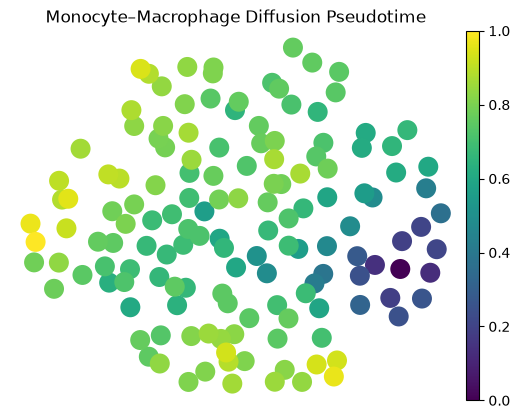

In [35]:
sc.pl.umap(
    mono_macro_hvg,
    color="dpt_pseudotime",
    title="Monocyte–Macrophage Diffusion Pseudotime",
    frameon=False,
    show=False
)

plt.savefig(
    figures_dir / "07_monocyte_macrophage_pseudotime_umap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

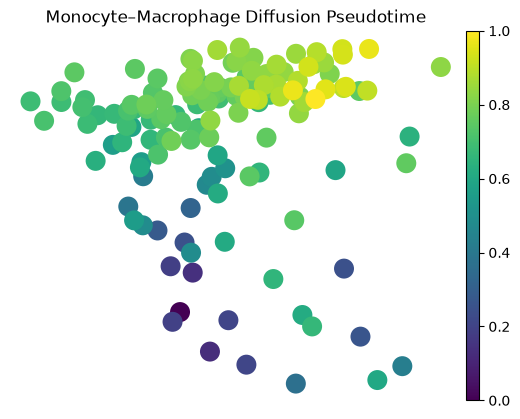

In [36]:
sc.pl.embedding(
    mono_macro_hvg,
    basis="diffmap",
    color="dpt_pseudotime",
    components=["1,2"],
    frameon=False,
    title="Monocyte–Macrophage Diffusion Pseudotime",
    show=False
)

plt.savefig(
    figures_dir / "07_monocyte_macrophage_diffusion_pseudotime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
print("=== FINAL MYELOID TRAJECTORY QC ===")

print(f"Monocyte–macrophage cells analysed: {mono_macro_hvg.n_obs}")
print(f"Trajectory HVGs: {mono_macro_hvg.n_vars}")

print("\nPopulation composition:")
print(
    mono_macro_hvg.obs["celltype_minor"]
    .value_counts()
)

print("\nSelected root cell:")
print(root_cell)

print("\nPseudotime range:")
print(
    mono_macro_hvg.obs["dpt_pseudotime"]
    .agg(["min", "max"])
)

print("\nSubset pseudotime summary:")
print(subset_pseudotime.round(3))

print("\nProgramme correlations with pseudotime:")
print("Monocyte score:   rho = -0.102, p = 0.2205")
print("Macrophage score: rho = 0.178, p = 0.0323")

print("\nInterpretation:")
print(
    "Diffusion pseudotime suggested a weak monocyte-to-macrophage "
    "transcriptional continuum. Macrophage-associated programme scores "
    "increased significantly along pseudotime, whereas the monocyte "
    "programme showed a non-significant decreasing trend."
)

=== FINAL MYELOID TRAJECTORY QC ===
Monocyte–macrophage cells analysed: 145
Trajectory HVGs: 1207

Population composition:
celltype_minor
Macrophage    109
Monocyte       36
Name: count, dtype: int64

Selected root cell:
CID4465_TTAGGACGTTGCGTTA

Pseudotime range:
min    0.0
max    1.0
Name: dpt_pseudotime, dtype: float32

Subset pseudotime summary:
                                count   mean  median
celltype_subset                                     
Myeloid_c8_Monocyte_2_S100A9        3  0.193   0.187
Myeloid_c2_LAM2_APOE                1  0.366   0.366
Myeloid_c12_Monocyte_1_IL1B        33  0.602   0.637
Myeloid_c1_LAM1_FABP5             102  0.739   0.753
Myeloid_c9_Macrophage_2_CXCL10      5  0.785   0.774
Myeloid_c10_Macrophage_1_EGR1       1  0.867   0.867

Programme correlations with pseudotime:
Monocyte score:   rho = -0.102, p = 0.2205
Macrophage score: rho = 0.178, p = 0.0323

Interpretation:
Diffusion pseudotime suggested a weak monocyte-to-macrophage transcriptional cont

## Conclusion

Diffusion pseudotime analysis of 145 monocyte and macrophage cells suggested
a weak transcriptional continuum between monocyte-enriched and
macrophage-dominated states.

Cells annotated as S100A9-positive monocytes occupied earlier pseudotime
positions, while the dominant LAM1/FABP5 macrophage population and minor
CXCL10- and EGR1-associated macrophage subsets tended to occur later.

Macrophage-associated transcriptional activity showed a weak but statistically
significant positive correlation with pseudotime (Spearman rho = 0.178,
p = 0.0323). In contrast, the monocyte-associated programme showed a
non-significant negative trend (rho = -0.102, p = 0.2205).

These findings support an exploratory monocyte-to-macrophage transcriptional
continuum within the CID4465 TNBC microenvironment, but should not be
interpreted as direct evidence of temporal differentiation or lineage fate.